### **Description**

Recipe showing how to extract the RAPID-MOCHA trans-basin array at 26.5°N using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do atmospheric forcing from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
The RAPID-MOCHA trans-basin array at 26.5°N is the longest-running basin-wide AMOC monitoring array, providing continuous time series of meridional volume and heat transport across the basin since April 2004 (e.g., Moat et al., 2025; McCarthy et al., 2015).

The array comprises full-depth moored temperature, salinity, and velocity measurements along the western and the eastern boundaries, submarine cables to estimate Florida Strait transport, and Ekman transport estimated from ERA5 winds.

The vertical overturning stream function is used to characterise the strength and structure of the AMOC in depth-space across the RAPID-MOCHA array and can be defined at time $t$ as follows:

$$\Psi_{z}(z, t) = \int_{z}^{\eta} \int_{x_w}^{x_e} v(x, z, t) \ dx \ dz$$

where the velocity field $v(x, z, t)$ normal to the RAPID-MOCHA array is first integrated zonally between the western $x_w$ and eastern $x_e$ boundaries of the basin, before being accumulated from the sea surface $\eta$ to a specified depth $z$.

---

In [1]:
# -- Import required packages -- #
import gsw
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/',
                 'local_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/'
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=5, threads_per_worker=2, memory_limit='8GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [2]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/50)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to open the conservative temperature and absolute salinity variables stored at T-points as a single dataset.**

**Here, for simplicity, we will only consider the time-period from 2004-2023 overlapping with RAPID-MOCHA observations**

In [3]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including conservative temperature (deg C) and absolute salinity (g/kg) variables:
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={}).sel(time_counter=slice("2004-01", "2023-12"))

# Calculate potential density anomaly referenced to the sea surface (kg/m3):
ds_gridT['sigma0'] = gsw.density.sigma0(CT=ds_gridT['thetao_con'], SA=ds_gridT['so_abs'])
ds_gridT['sigma0'].name = 'sigma0'

ds_gridT

<xarray.Dataset> Size: 18GB
Dimensions:                (time_counter: 20, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 160B 2004-07-02 ... ...
    time_centered          (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/75)
    berg_latent_heat_flux  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    vohfcisf               (time_counter, deptht, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    sigma0                 (time_counter, deptht, y, x) float64 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

**Next, we need to import the zonal & meridional velocities and vertical grid cell thicknesses stored at U- & V-points, respectively.**

In [4]:
# Define directory path to model output files:
gridU_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1y"

# Construct NEMO model U-grid dataset, including zonal velocities (m/s) and vertical grid cell thicknesses (m):
ds_gridU = xr.open_zarr(gridU_url, consolidated=True, chunks={}).sel(time_counter=slice("2004-01", "2023-12"))

ds_gridU

<xarray.Dataset> Size: 4GB
Dimensions:               (depthu: 75, axis_nbounds: 2, time_counter: 20,
                           y: 331, x: 360)
Coordinates:
  * depthu                (depthu) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/14)
    depthu_bounds         (depthu, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3u                   (time_counter, depthu, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfx                   (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_adv               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_diff              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    sozosatr              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 320B dask.array<chunksize=(1, 2), meta=np.ndarray>
    u2o                   (time_counter, depthu, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo                   (time_counter, depthu, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo_vint              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    uo                    (time_counter, depthu, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    uo_eiv                (time_counter, depthu, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_U
    description:  ocean U grid variables
    title:        ocean U grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         8156ec68-1106-4f56-9f8c-d8798e1bd32f

In [5]:
# Define directory path to model output files:
gridV_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1y"

# Construct NEMO model V-grid dataset, including meridional velocities (m/s) and vertical grid cell thicknesses (m):
ds_gridV = xr.open_zarr(gridV_url, consolidated=True, chunks={}).sel(time_counter=slice("2004-01", "2023-12"))

ds_gridV

<xarray.Dataset> Size: 4GB
Dimensions:               (depthv: 75, axis_nbounds: 2, time_counter: 20,
                           y: 331, x: 360)
Coordinates:
  * depthv                (depthv) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/13)
    depthv_bounds         (depthv, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfy                   (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_adv               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_diff              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    somesatr              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 320B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 320B dask.array<chunksize=(1, 2), meta=np.ndarray>
    v2o                   (time_counter, depthv, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vmo                   (time_counter, depthv, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo                    (time_counter, depthv, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo_eiv                (time_counter, depthv, y, x) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T, U & V-grid variables for the eORCA1 model.**

In [6]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent":
            {"domain": ds_domain,
             "gridT": ds_gridT,
             "gridU": ds_gridU,
             "gridV": ds_gridV
             }
            }

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 20, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
│       time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 320B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 320B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 20, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│           time_centered          (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/81)
│           berg_latent_heat_flux  (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 715MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e3t_0                  (k, j, i) float64 71MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           ht_0                   (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           name:         OUTPUT/eORCA1_1y_grid_T
│           description:  ocean T grid variables
│           title:        ocean T grid variables
│           Conventions:  CF-1.6
│           timeStamp:    2024-Dec-09 10:28:01 GMT
│           uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b
│           nftype:       F
│           iperio:       True
├── Group: /gridU
│       Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 20, j: 331,
│                                  i: 360)
│       Coordinates:
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * depthu                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) f

### **Extracting the RAPID-MOCHA array as a zonal hydrographic section**

**Now, let's extract an approximately zonal section at the latitude of the RAPID-MOCHA array from our NEMODataTree.**

**The resulting hydrographic section will be defined on the NEMO model V-grid at the constant j-coordinate whose average latitude is closest to 26.5°N.**

**We need to provide the names of the zonal vector variables (e.g., `u_vars=["tauuo"]`) and any scalar variables (e.g., `scalar_vars=['thetao_con', 'so_abs']`) to be linearly interpolated onto the V-grid.**

In [7]:
# Extract the RAPID-MOCHA array from the NEMO model data:
ds_rapid = nemo.extract_zonal_section(lat=26.5,
                                      lon_min=-82.0,
                                      lon_max=-10.0,
                                      u_vars=None,
                                      scalar_vars=['thetao_con', 'so_abs'],
                                      dom='.'
                                      )

ds_rapid

<xarray.Dataset> Size: 4MB
Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 20, bdy: 72)
Coordinates:
  * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
  * depthb                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
  * i                     (bdy) int64 576B 206 207 208 209 ... 274 275 276 277
    gphib                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    glamb                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    j                     float64 8B 229.5
Dimensions without coordinates: axis_nbounds, bdy
Data variables: (12/23)
    depthv_bounds         (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3b                   (time_counter, k, bdy) float32 432kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    hfy                   (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_adv               (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_diff              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    somesatr              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    ...                    ...
    e3b_0                 (k, bdy) float64 43kB dask.array<chunksize=(75, 72), meta=np.ndarray>
    hb_0                  (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    thetao_con            (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    so_abs                (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    i_bdy                 (bdy) int64 576B 206 207 208 209 ... 274 275 276 277
    j_bdy                 (bdy) float64 576B 229.5 229.5 229.5 ... 229.5 229.5
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

**Taking a closer look at our hydrographic section dataset, we can see it is structured analogously to a NEMO model grid node within our `NEMODataTree`:**

* Inherited NEMO Grid Dimension: `k`

* New Along-Boundary Grid Dimension: `bdy`, such that `i_bdy(bdy)`, `j_bdy(bdy)`

* Geographical Coordinates: `glamb` (longitude), `gphib` (latitude).

* Horizontal Grid Scale Factors: `e1b`, `e2b`

* Vertical Grid Scale Factors: `e3b`

* Land-Sea Masks: `bmask`, `bmaskutil`


### **Visualising properties along the RAPID-MOCHA array**

**Next, let's plot the time-mean conservative temperature along the RAPID-MOCHA array:**

(6000.0, 0.0)

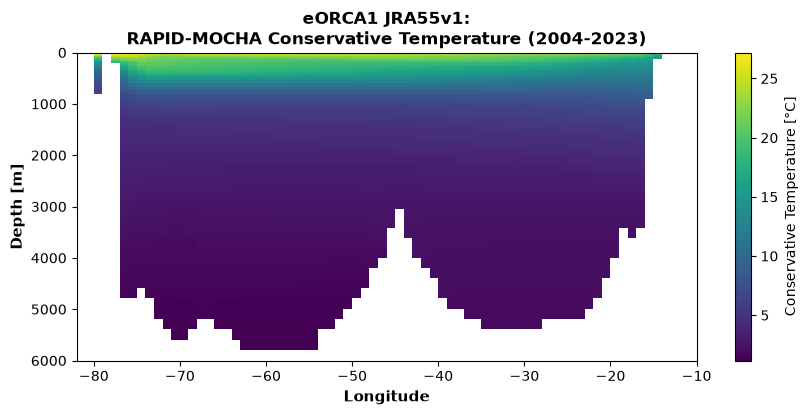

In [8]:
# -- Plot the time-mean conservative temperature along the RAPID-MOCHA section -- #
plt.figure(figsize=(10, 4))

# Plot time-mean conservative temperature across RAPID-MOCHA section:
ds_rapid['thetao_con'].mean(dim='time_counter').plot(x='glamb', y='depthb', yincrease=False, cbar_kwargs={"label": "Conservative Temperature [°C]"})

# Axes labels:
plt.title("eORCA1 JRA55v1:\nRAPID-MOCHA Conservative Temperature (2004-2023)", fontdict={'size':12, 'weight':'bold'})
plt.xlabel("Longitude", fontdict={'size':11, 'weight':'bold'})
plt.ylabel("Depth [m]", fontdict={'size':11, 'weight':'bold'})
plt.ylim([6000, 0])

### **Calculating Meridional Overturning Stream Function along the RAPID-MOCHA array**

**Now, let's calculate the meridional overturning stream function in depth coordinates along the RAPID-MOCHA array.**

**To ensure consistency with RAPID-MOCHA observational estimates, we first introduce a uniform compensation velocity $v_{c}(t)$ such that the net volume transport across the zonal section is zero at each output time. The compensation is applied uniformly over the section to obtain the adjusted velocity field $v^{*}(t, k, bdy)$.**

$$v^{*}(t, k, \mathrm{bdy}) = v(t, k, \mathrm{bdy}) + v_c(t)$$

where

$$v_c(t) = -\frac{V(t)}{\displaystyle \sum_{\mathrm{bdy}} \sum_k e_{1b}\, e_{3b}}$$

and $V(t)$ is the net volume transport across the section, and $e_{1b}$ and $e_{3b}$ are the zonal and vertical grid scale factors defined along the section, respectively.

In [9]:
# Define grid cell face area variables (m2):
ds_rapid['area'] = ds_rapid['e3b'] * ds_rapid['e1b']
ds_rapid['area'].name = 'area'

# Calculate volume transport = seawater velocity x grid cell face area [m3/s]:
ds_rapid['vto'] = ds_rapid['vo'] * ds_rapid['area']

# Calculate compensation volume transport = - net volume transport across the RAPID-MOCHA array [m3/s]:
ds_rapid['vto_comp'] = -ds_rapid['vto'].sum(dim=['k', 'bdy'])

# Calculate uniform compensation velocity = - net volume transport / total grid cell face area [m/s]:
ds_rapid['vo_comp'] = ds_rapid['bmask'] * (ds_rapid['vto_comp'] / ds_rapid['area'].sum(dim=['k', 'bdy']))

# Calculate adjusted seawater velocity [m/s]:
ds_rapid['vo_adj'] = ds_rapid['vo'] + ds_rapid['vo_comp']

# Calculate adjusted volume transport [m3/s]:
ds_rapid['vto_adj'] = ds_rapid['vo_adj'] * ds_rapid['area']

ds_rapid

<xarray.Dataset> Size: 8MB
Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 20, bdy: 72)
Coordinates:
  * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
  * depthb                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
  * i                     (bdy) int64 576B 206 207 208 209 ... 274 275 276 277
    gphib                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    glamb                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    j                     float64 8B 229.5
Dimensions without coordinates: axis_nbounds, bdy
Data variables: (12/29)
    depthv_bounds         (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3b                   (time_counter, k, bdy) float32 432kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    hfy                   (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_adv               (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_diff              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    somesatr              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    ...                    ...
    area                  (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    vto                   (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    vto_comp              (time_counter) float64 160B dask.array<chunksize=(1,), meta=np.ndarray>
    vo_comp               (k, bdy, time_counter) float64 864kB dask.array<chunksize=(75, 72, 1), meta=np.ndarray>
    vo_adj                (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    vto_adj               (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

**Next, let's calculate the vertical overturning stream function by approximating the vertical coordinate $k$ coordinates for depth coordinates.**

**Note, both the vertical grid cell thickness and depth of each grid cell are in-fact evolving through time when using `zps` vertical coordinates, however, we will choose to neglect these small variations for simplicity here.**

In [10]:
# Calculate meridional overturning circulation (MOC) streamfunction [Sv]:
ds_rapid['moc_k'] = 1E-6 * ds_rapid['vto_adj'].sum(dim=['bdy']).cumsum(dim='k')

ds_rapid

<xarray.Dataset> Size: 8MB
Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 20, bdy: 72)
Coordinates:
  * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
  * depthb                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 160B 2004-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 160B dask.array<chunksize=(1,), meta=np.ndarray>
  * i                     (bdy) int64 576B 206 207 208 209 ... 274 275 276 277
    gphib                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    glamb                 (bdy) float64 576B dask.array<chunksize=(72,), meta=np.ndarray>
    j                     float64 8B 229.5
Dimensions without coordinates: axis_nbounds, bdy
Data variables: (12/30)
    depthv_bounds         (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3b                   (time_counter, k, bdy) float32 432kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    hfy                   (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_adv               (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    hfy_diff              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    somesatr              (time_counter, bdy) float32 6kB dask.array<chunksize=(1, 72), meta=np.ndarray>
    ...                    ...
    vto                   (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    vto_comp              (time_counter) float64 160B dask.array<chunksize=(1,), meta=np.ndarray>
    vo_comp               (k, bdy, time_counter) float64 864kB dask.array<chunksize=(75, 72, 1), meta=np.ndarray>
    vo_adj                (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    vto_adj               (time_counter, k, bdy) float64 864kB dask.array<chunksize=(1, 25, 72), meta=np.ndarray>
    moc_k                 (time_counter, k) float64 12kB dask.array<chunksize=(1, 25), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Visualising the time-mean vertical overturning stream function**

**Finally, let's visualise the results by plotting the time-mean RAPID-MOCHA vertical overturning stream function:**

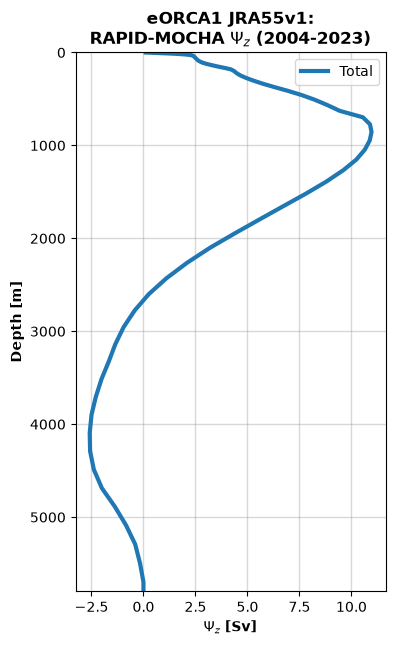

In [12]:
# Plot time-mean diapycnal overturning stream functions along the OSNAP section:
plt.figure(figsize=(4, 7))
plt.grid(True, lw=1, color='0.5', alpha=0.3)

# Plot RAPID-MOCHA Total vertical overturning stream function:
ds_rapid['moc_k'].mean(dim='time_counter').plot(yincrease=False, y='depthb', label='Total', lw=3)

# Axes labels:
plt.title("eORCA1 JRA55v1:\nRAPID-MOCHA $\\Psi_{z}$ (2004-2023)", fontdict={"size": 12, "weight": "bold"})
plt.xlabel("$\\Psi_{z}$ [Sv]", fontdict={"size": 10, "weight": "bold"})
plt.ylabel("Depth [m]", fontdict={"size": 10, "weight": "bold"})
plt.ylim([5800, 0])
plt.legend()